In [1]:
import pandas as pd
import numpy as np
import os 

In [2]:
data_path = "../../data/"
order_products_path = os.path.join(data_path, "order_products__prior.csv")


baskets = pd.read_csv(order_products_path)
baskets.head()

# For the calculation of baksets
num_unique_items = baskets["product_id"].nunique()

In [3]:
baskets = baskets.groupby("order_id")["product_id"].apply(list)
baskets.head()

order_id
2    [33120, 28985, 9327, 45918, 30035, 17794, 4014...
3    [33754, 24838, 17704, 21903, 17668, 46667, 174...
4    [46842, 26434, 39758, 27761, 10054, 21351, 225...
5    [13176, 15005, 47329, 27966, 23909, 48370, 132...
6                                [40462, 15873, 41897]
Name: product_id, dtype: object

Count single items

In [4]:
from collections import Counter
item_counts = Counter()

for basket in baskets:
    item_counts.update(basket)

In [5]:
support_percentage = 0.001     # 0.1%
support_threshold = int(len(baskets) * support_percentage)
support_threshold

3214

Bucket sizes: [49677, 74515, 99354, 149031]

--- Testing bucket size 49677 ---
  Support 0.001 → threshold 3214
  Support 0.002 → threshold 6429
  Support 0.005 → threshold 16074
  Support 0.01 → threshold 32148

--- Testing bucket size 74515 ---
  Support 0.001 → threshold 3214
  Support 0.002 → threshold 6429
  Support 0.005 → threshold 16074
  Support 0.01 → threshold 32148

--- Testing bucket size 99354 ---
  Support 0.001 → threshold 3214
  Support 0.002 → threshold 6429
  Support 0.005 → threshold 16074
  Support 0.01 → threshold 32148

--- Testing bucket size 149031 ---
  Support 0.001 → threshold 3214
  Support 0.002 → threshold 6429
  Support 0.005 → threshold 16074
  Support 0.01 → threshold 32148

Result matrix:

[[48381  4441   195    21]
 [24381  1904   145    19]
 [10924  1274   120    19]
 [ 5473   942   113    19]]


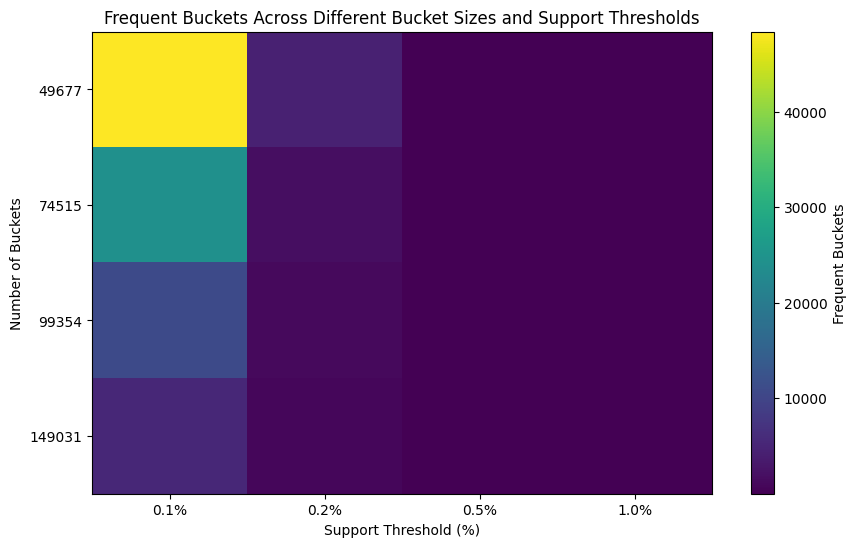

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Multipliers based on theory (1x, 1.5x, 2x, 3x)
multipliers = [1.0, 1.5, 2.0, 3.0]

# Support percentages for testing PCY Pass 1
support_percentages = [0.001, 0.002, 0.005, 0.01]  # 0.1%, 0.2%, 0.5%, 1%

# Calculate bucket sizes
bucket_options = [int(num_unique_items * m) for m in multipliers]
print("Bucket sizes:", bucket_options)

# Store results in a matrix: rows = multipliers, columns = support thresholds
results = np.zeros((len(multipliers), len(support_percentages)), dtype=int)

for i, num_buckets in enumerate(bucket_options):
    print(f"\n--- Testing bucket size {num_buckets} ---")
    
    for j, sp in enumerate(support_percentages):
        support_threshold = int(len(baskets) * sp)
        print(f"  Support {sp} → threshold {support_threshold}")
        
        bucket_counts = np.zeros(num_buckets, dtype=int)
        
        # Hashing pairs
        for basket in baskets:
            b = sorted(basket)
            for a in range(len(b)):
                for c in range(a + 1, len(b)):
                    h = (b[a] * 13 + b[c] * 7) % num_buckets
                    bucket_counts[h] += 1
        
        frequent_buckets = (bucket_counts >= support_threshold).sum()
        results[i, j] = frequent_buckets

print("\nResult matrix:\n")
print(results)

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.imshow(results, cmap='viridis', aspect='auto')
plt.colorbar(label="Frequent Buckets")

plt.xticks(range(len(support_percentages)), [f"{p*100:.1f}%" for p in support_percentages])
plt.yticks(range(len(bucket_options)), bucket_options)

plt.xlabel("Support Threshold (%)")
plt.ylabel("Number of Buckets")
plt.title("Frequent Buckets Across Different Bucket Sizes and Support Thresholds")
plt.show()


### Selection of Bucket Size and Support Threshold

The combination of a bucket size equal to approximately 1.5× the number of unique products (≈75,000 buckets) and a support threshold of 0.5% was chosen based on the PCY Pass 1 evaluation matrix.  
This configuration provides balanced filtering: smaller bucket sizes produced excessive collisions, while larger sizes led to overly sparse bitmaps.  
At 75k buckets and 0.5% support, the number of frequent buckets remained low enough to ensure efficient pruning, while still preserving meaningful candidate pairs for Pass 2.  

## PCY Pass 1 – Saved State (Checkpoint)

This notebook has completed the full PCY Pass 1 process, including:
- Loading and preprocessing the Instacart data  
- Creating baskets  
- Counting single items  
- Testing multiple bucket sizes  
- Testing multiple support thresholds  
- Running the full hashing procedure  
- Building the frequent-bucket matrix  

To avoid re-running the 38-minute computation, the following objects have been saved to `pcy_pass1_results.pkl`:

- `baskets`  
- `num_unique_items`  
- `bucket_options`  
- `support_percentages`  
- `results` (frequent bucket matrix)


In [9]:
import pickle

save_dir = "../../data/Georgios/pcy_pass1"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "pcy_pass1_results.pkl")

save_data = {
    "baskets": baskets,
    "num_unique_items": num_unique_items,
    "bucket_options": bucket_options,
    "support_percentages": support_percentages,
    "results": results
}

with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved at: {save_path}")

Saved at: ../../data/Georgios/pcy_pass1\pcy_pass1_results.pkl
